# Proyek Analisis Data: [Air Quality Dataset]
- **Nama:** [Muhammad Farhan]
- **Email:** [cdcc325d6y1759@student.devacademy.id]
- **ID Dicoding:** [muhammad_farhan_l0ox]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

1. **Pada bulan apa rata-rata PM2.5 paling tinggi dan paling rendah selama periode 2013–2017?**  

2. **Bagaimana rata-rata PM2.5 berubah berdasarkan kategori kecepatan angin selama periode 2013–2017?**  
   

## Import Semua Packages/Library yang Digunakan

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

## Data Wrangling

### Gathering Data
Dataset diperoleh dari file CSV beberapa stasiun kualitas udara di Beijing. Seluruh data digabung menjadi satu DataFrame untuk mempermudah analisis.

#### Load df ...

In [32]:
# ambil semua file csv
csv_files = glob.glob("data/PRSA_Data_*20130301-20170228.csv")

# kalau notebook dijalankan di folder yang sama dengan csv
if len(csv_files) == 0:
    csv_files = glob.glob("PRSA_Data_*20130301-20170228.csv")

print("Jumlah file ditemukan:", len(csv_files))
print(csv_files)

# baca dan gabungkan semua file
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)

# buat kolom datetime
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

df.head()

Jumlah file ditemukan: 12
['PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Aotizhongxin_20130301-20170228.csv']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou,2013-03-01 01:00:00
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou,2013-03-01 04:00:00


**Insight:** (Opsional)
- Data mentah sudah berhasil digabungkan dari seluruh stasiun sehingga analisis dapat dilakukan pada level gabungan maupun per stasiun.

### Assessing Data

Mencari masalah pada data yang perlu di bersihkan

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        420768 non-null  int64         
 1   year      420768 non-null  int64         
 2   month     420768 non-null  int64         
 3   day       420768 non-null  int64         
 4   hour      420768 non-null  int64         
 5   PM2.5     412029 non-null  float64       
 6   PM10      414319 non-null  float64       
 7   SO2       411747 non-null  float64       
 8   NO2       408652 non-null  float64       
 9   CO        400067 non-null  float64       
 10  O3        407491 non-null  float64       
 11  TEMP      420370 non-null  float64       
 12  PRES      420375 non-null  float64       
 13  DEWP      420365 non-null  float64       
 14  RAIN      420378 non-null  float64       
 15  wd        418946 non-null  object        
 16  WSPM      420450 non-null  float64    

In [34]:
df.isna().sum().sort_values(ascending=False)

,0
CO,20701
O3,13277
NO2,12116
SO2,9021
PM2.5,8739
PM10,6449
wd,1822
DEWP,403
TEMP,398
PRES,393


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
No,420768.0,17532.5,1.0,8766.75,17532.5,26298.25,35064.0,10122.116943
year,420768.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177198
month,420768.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448707
day,420768.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800102
hour,420768.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922195
PM2.5,412029.0,79.793428,2.0,20.0,55.0,111.0,999.0,80.822391
PM10,414319.0,104.602618,2.0,36.0,82.0,145.0,999.0,91.772426
SO2,411747.0,15.830835,0.2856,3.0,7.0,20.0,500.0,21.650603
NO2,408652.0,50.638586,1.0265,23.0,43.0,71.0,290.0,35.127912
CO,400067.0,1230.766454,100.0,500.0,900.0,1500.0,10000.0,1160.182716


In [37]:
# Cek nilai tidak wajar / placeholder
summary_check = df[["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]].describe().T
summary_check[["min","max"]]


,min,max
PM2.5,2.0000,999.0
PM10,2.0000,999.0
SO2,0.2856,500.0
NO2,1.0265,290.0
CO,100.0000,10000.0
O3,0.2142,1071.0
TEMP,-19.9000,41.6
PRES,982.4000,1042.8
DEWP,-43.4000,29.1
RAIN,0.0000,72.5


**Steps to Take:**
- Mengubah nilai `999` menjadi `NaN`.
- Mengisi missing value numerik dengan median per stasiun.
- Jika masih ada nilai hilang, gunakan median keseluruhan.
- Mengisi missing value kategorikal `wd` dengan modus.
- Menghapus kolom `No` karena hanya nomor urut dan tidak diperlukan untuk analisis.


**Insight:** (Opsional)
1. **Missing value** pada beberapa kolom, terutama CO, O3, NO2, SO2, PM2.5, dan PM10.
2. **Invalid value** berupa angka `999` pada kolom PM2.5 dan PM10 yang berfungsi sebagai placeholder nilai hilang.
3. Tidak ditemukan duplicate row pada dataset gabungan.


### Cleaning Data

#### Fixing ... problem

In [38]:
df_clean = df.copy()

# Ubah placeholder menjadi NaN
df_clean.loc[df_clean["PM2.5"] == 999, "PM2.5"] = np.nan
df_clean.loc[df_clean["PM10"] == 999, "PM10"] = np.nan

# Buat kolom datetime
df_clean["datetime"] = pd.to_datetime(df_clean[["year", "month", "day", "hour"]])

# Imputasi numerik dengan median per stasiun
num_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean.groupby("station")[col].transform("median"))
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Imputasi kategorikal
df_clean["wd"] = df_clean["wd"].fillna(df_clean["wd"].mode()[0])

# Hapus kolom yang tidak diperlukan
df_clean = df_clean.drop(columns=["No"])

# Kategori kecepatan angin
df_clean["wind_category"] = pd.cut(
    df_clean["WSPM"],
    bins=[-0.001, 1, 3, 6, np.inf],
    labels=["Lemah", "Sedang", "Kuat", "Sangat Kuat"]
)

df_clean.isna().sum().sort_values(ascending=False).head(10)


,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0


In [39]:
df_clean.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime,wind_category
0,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou,2013-03-01 00:00:00,Kuat
1,2013,3,1,1,4.0,4.0,3.0,25.0,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou,2013-03-01 01:00:00,Sedang
2,2013,3,1,2,4.0,4.0,4.0,25.0,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou,2013-03-01 02:00:00,Sedang
3,2013,3,1,3,3.0,3.0,3.0,2.0,800.0,49.0,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou,2013-03-01 03:00:00,Sedang
4,2013,3,1,4,3.0,3.0,7.0,25.0,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou,2013-03-01 04:00:00,Sedang


**Insight:** (Opsional)
- Setelah cleaning, dataset siap dipakai untuk analisis. Kolom penting sudah bersih dari missing value dan placeholder tidak valid.

## Exploratory Data Analysis (EDA)

### Explore ...

In [40]:
df_clean[["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "WSPM"]].describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,79.270794,104.229102,15.642997,50.384959,1212.909829,56.925748,13.539869,1.729444
std,80.051576,91.092075,21.456742,34.714968,1134.271612,55.830557,11.430772,1.245961
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,0.000000
25%,21.000000,36.000000,3.000000,23.000000,500.000000,12.000000,3.100000,0.900000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,44.000000,14.500000,1.400000
75%,109.000000,144.000000,19.000000,70.000000,1500.000000,80.000000,23.200000,2.200000
max,957.000000,995.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,13.200000


In [41]:
# Rata-rata PM2.5 per bulan
monthly_pm25 = df_clean.groupby("month")["PM2.5"].mean().reindex(range(1, 13))
monthly_pm25

,PM2.5
month,
1,93.208821
2,86.852142
3,94.205038
4,72.291285
5,62.835531
6,68.754661
7,71.281734
8,53.508994
9,61.315729


In [42]:
# Rata-rata PM2.5 berdasarkan kategori kecepatan angin
wind_pm25 = (
    df_clean.groupby("wind_category", observed=True)["PM2.5"]
    .mean()
    .reindex(["Lemah", "Sedang", "Kuat", "Sangat Kuat"])
)
wind_pm25

,PM2.5
wind_category,
Lemah,100.908876
Sedang,76.913249
Kuat,36.382834
Sangat Kuat,27.021657


**Insight:** (Opsional)
- xPM2.5 cenderung lebih tinggi pada bulan akhir/tahun awal.
- Kategori angin yang lebih kuat cenderung diikuti rata-rata PM2.5 yang lebih rendah.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

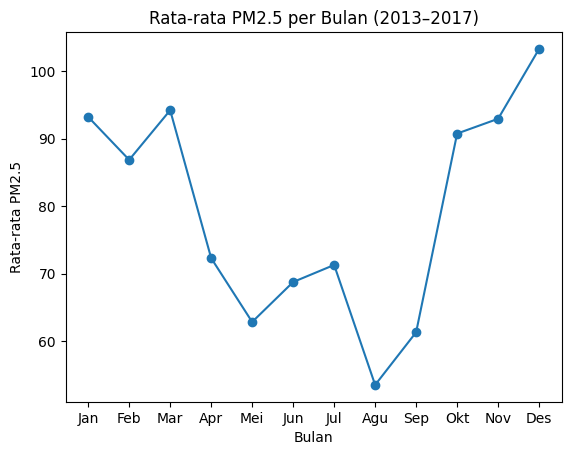

In [43]:
month_labels = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "Mei", 6: "Jun",
    7: "Jul", 8: "Agu", 9: "Sep", 10: "Okt", 11: "Nov", 12: "Des"
}

fig, ax = plt.subplots()
ax.plot(monthly_pm25.index, monthly_pm25.values, marker="o")
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_labels[i] for i in range(1, 13)])
ax.set_xlabel("Bulan")
ax.set_ylabel("Rata-rata PM2.5")
ax.set_title("Rata-rata PM2.5 per Bulan (2013–2017)")
plt.show()

### Pertanyaan 2:

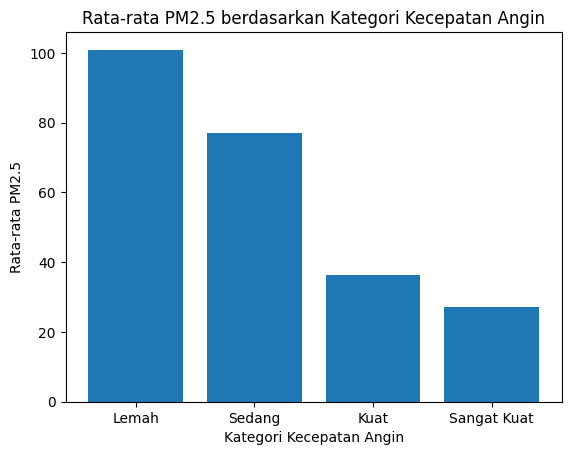

In [44]:
fig, ax = plt.subplots()
ax.bar(wind_pm25.index.astype(str), wind_pm25.values)
ax.set_xlabel("Kategori Kecepatan Angin")
ax.set_ylabel("Rata-rata PM2.5")
ax.set_title("Rata-rata PM2.5 berdasarkan Kategori Kecepatan Angin")
plt.show()

**Insight:** (Opsional)
- rata-rata PM2.5 paling tinggi terjadi pada Desember, sedangkan yang paling rendah terjadi pada Agustus.
- semakin tinggi kategori kecepatan angin, rata-rata PM2.5 cenderung semakin rendah.

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** ata-rata PM2.5 paling tinggi terjadi pada Desember, sedangkan yang paling rendah terjadi pada Agustus. Ini menunjukkan bahwa kualitas udara cenderung lebih buruk di akhir tahun dan lebih baik di pertengahan tahun.
- **Conclusion pertanyaan 2:** semakin tinggi kategori kecepatan angin, rata-rata PM2.5 cenderung semakin rendah. Kategori Sangat Kuat biasanya menunjukkan PM2.5 paling kecil, sedangkan kategori Lemah paling tinggi. Artinya, angin yang lebih kuat membantu menyebarkan polutan.


**Rekomendasi Action Item:**
- Perkuat pemantauan kualitas udara dan peringatan publik pada periode **Oktober–Desember** karena PM2.5 cenderung meningkat.
- Gunakan informasi kecepatan angin sebagai sinyal pendukung untuk sistem alert kualitas udara, terutama saat angin lemah.
- Siapkan strategi mitigasi polusi pada bulan-bulan dengan risiko tinggi, misalnya pembatasan aktivitas tertentu atau pengawasan emisi yang lebih ketat.
-

In [45]:
from google.colab import files

# Save the cleaned DataFrame to a CSV file
df_clean.to_csv('main_data.csv', index=False)

# Provide a download link for the user
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>